### Data loading

In [18]:
import trimap
import pandas as pd

In [19]:
chronos = pd.read_csv("../data/CRISPR_gene_effect.csv",index_col=0)
chronos.columns = [c.split()[0].upper() + '_Chronos' for c in chronos.columns]
expression = pd.read_csv("../data/CCLE_expression.csv", index_col=0)
expression.columns = [c.split()[0].upper()+'_Expression' for c in expression.columns]
sample_info = pd.read_csv("../data/sample_info.csv", index_col=0)
ch_ex = chronos.merge(expression, right_index=True, left_index=True).dropna()

In [20]:
import pandas as pd
D = pd.read_csv("../data/D_22Q2.csv", index_col=0)
ch_ex_D = ch_ex.merge(D,left_index=True, right_index=True, how='left').copy()

In [21]:
id_to_name = {i:n for i, n in zip(sample_info.index, sample_info["stripped_cell_line_name"])}
name_to_id = {n:i for i, n in zip(sample_info.index, sample_info["stripped_cell_line_name"])}
name_to_lineage = {n:l for n, l in zip(sample_info["stripped_cell_line_name"], sample_info["lineage"])}
ch_ex_D.index = [id_to_name.get(n,n) for n in ch_ex_D.index]

In [22]:
import pandas as pd
cluster = pd.read_csv('../cluster_hippo_260904.csv', index_col=0)
default_embedding = pd.read_csv('../trimap_hippo_260904.csv', index_col=0)

In [23]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import networkx as nx
from sklearn.neighbors import kneighbors_graph

### Different numbers of knockout features (Fig. S4b)

In [24]:
hippo_exp=['YAP1','WWTR1','CCN1','AXL']

hippo_chr_2sigma=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1', 'ARHGAP35', 'RAP2B']
hippo_chr_25sigma=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1', 'ARHGAP35', 'RAP2B', 'CYRIB']
hippo_chr_3sigma=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
hippo_chr_4sigma=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
embeddings = []
reducer = trimap.TRIMAP(n_dims=2, n_outliers=10, n_inliers=10)

for hippo_chr in [hippo_chr_2sigma,hippo_chr_3sigma,hippo_chr_25sigma, hippo_chr_4sigma]:
    reducer = trimap.TRIMAP(n_dims=2, n_outliers=10, n_inliers=10)
    features = [gene.upper() + '_Chronos' for gene in hippo_chr] + [gene.upper() + '_Expression' for gene in hippo_exp] 
    scaled_data = StandardScaler().fit_transform(ch_ex[features]) 
    embedding = reducer.fit_transform(scaled_data)
    embeddings.append(embedding)

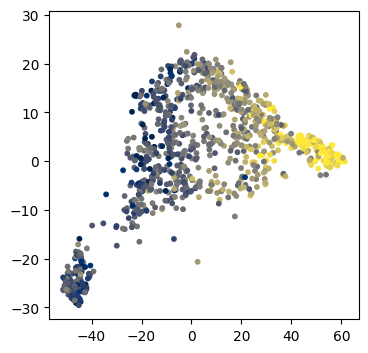

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
    
emb = embeddings[1]
#emb = default_embedding.values
plt.scatter(emb[:, 0], emb[:, 1], c=ch_ex_D['V8'], s=10, cmap='cividis',vmin=-0.05, vmax=0.05,alpha=1)
labels = cluster.values
#plt.scatter(emb[:, 0], emb[:, 1], c=labels, s=10, cmap='rainbow', alpha=1)
plt.savefig('../result/figure.svg')
plt.show()

### Different numbers of expression features (Fig. S5a, b)

In [28]:
#Fig. S5a, b
hippo_chr=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']

hippo_exp_0=[]
hippo_exp_2=['YAP1','WWTR1']
hippo_exp_4=['YAP1','WWTR1','CCN1','AXL']
hippo_exp_6=['YAP1','WWTR1','CCN1','AXL','FOSL1','CCDC80']
hippo_exp_8=['YAP1','WWTR1','CCN1','AXL','FOSL1','CCDC80','MYOF','ANXA2']

embeddings = []

for hippo_exp in [hippo_exp_0, hippo_exp_2, hippo_exp_4, hippo_exp_6, hippo_exp_8]:
    reducer = trimap.TRIMAP(n_dims=2, n_outliers=10, n_inliers=10)
    features = [gene.upper() + '_Chronos' for gene in hippo_chr] + [gene.upper() + '_Expression' for gene in hippo_exp] 
    scaled_data = StandardScaler().fit_transform(ch_ex[features]) 
    embedding = reducer.fit_transform(scaled_data)
    embeddings.append(embedding)

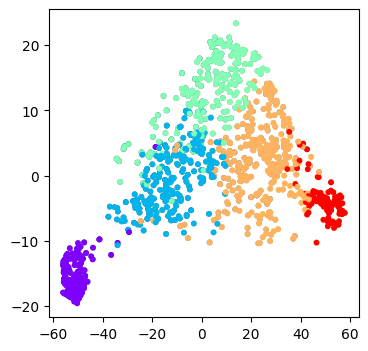

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
    
emb = embeddings[4]
#emb = default_embedding.values

labels = cluster.values
plt.scatter(emb[:, 0], emb[:, 1], c=ch_ex_D['V8'], s=10, cmap='cividis',vmin=-0.05, vmax=0.05,alpha=1)
plt.scatter(emb[:, 0], emb[:, 1], c=labels, s=10, cmap='rainbow', alpha=1)
plt.savefig('../result/figure.svg')
plt.show()

### Trimap inlier/outliers (Fig. S9)

In [ ]:
embeddings = {}

hippo_chr=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
hippo_exp=['YAP1','WWTR1','CCN1','AXL']

features = [gene.upper() + '_Chronos' for gene in hippo_chr] + [gene.upper() + '_Expression' for gene in hippo_exp] 
scaled_data = StandardScaler().fit_transform(ch_ex[features]) 

for n_inliers in [5, 10, 20, 100]:
    for n_outliers in [5, 10, 20, 100]:

        reducer = trimap.TRIMAP(
            n_dims=2,
            n_inliers=n_inliers,
            n_outliers=n_outliers
        )

        embedding = reducer.fit_transform(scaled_data)

        name = f"in{n_inliers}_out{n_outliers}"
        embeddings[name] = embedding

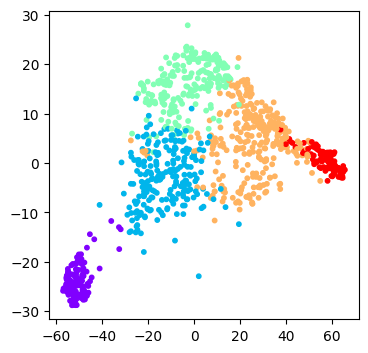

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
    
emb = embeddings['in10_out20']
#emb = default_embedding.values

labels = cluster.values
plt.scatter(emb[:, 0], emb[:, 1], c=labels, s=10, cmap='rainbow', alpha=1)
plt.savefig('../result/figure.svg')
plt.show()

### Different K in spectral clustering (Fig. S7e)

In [ ]:
#Fig. S7e
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import SpectralClustering
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from scipy.sparse.csgraph import connected_components

hippo_chr=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
hippo_exp=['YAP1','WWTR1','CCN1','AXL']

features = [gene.upper() + '_Chronos' for gene in hippo_chr] + [gene.upper() + '_Expression' for gene in hippo_exp] 
scaled_data = StandardScaler().fit_transform(ch_ex[features]) 
X = scaled_data
# -----------------------------
# 1. Build kNN affinity graph
# -----------------------------
labels_dic = {}
for n_neighbors in [10, 20, 30, 50]:
    # distance graph
    D = kneighbors_graph(
        X,
        n_neighbors=n_neighbors,
        mode="distance",
        include_self=False
    )

    # symmetrize distance graph
    D = D.maximum(D.T)

    # convert distances to RBF-like affinities only on kNN edges
    nonzero_dist = D.data
    sigma = np.median(nonzero_dist)

    A = D.copy()
    A.data = np.exp(-(A.data ** 2) / (2 * sigma ** 2))

    # check graph connectivity
    n_components, component_labels = connected_components(A)


    spectral = SpectralClustering(
        n_clusters=5,
        affinity="precomputed",
        assign_labels="cluster_qr",
        random_state=0
    )
    labels = spectral.fit_predict(A)
    labels_dic[n_neighbors] = labels




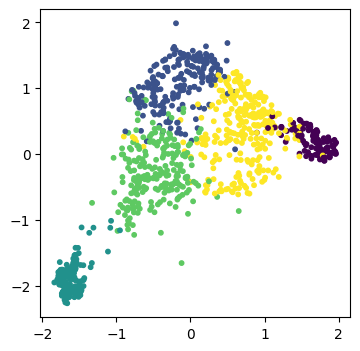

In [170]:
plt.figure(figsize=(4,4))
labels = labels_dic[50]
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, s=10, cmap="viridis")
plt.savefig('../result/figure.svg')
plt.show()


In [ ]:
from sklearn.metrics import adjusted_rand_score
labels_true = pd.read_csv('../cluster_hippo_260904.csv', index_col=0).values.flatten()
for n_neighbors, labels_pred in labels_dic.items():
    ari = adjusted_rand_score(labels_true, labels_pred)
    print(f"n_neighbors={n_neighbors}, ARI={ari}")


n_neighbors=10, ARI=0.914477264383598
n_neighbors=20, ARI=0.9214630072932566
n_neighbors=30, ARI=1.0
n_neighbors=50, ARI=0.9119052654265536


### Diffent cluster numbers (Fig. S7a-d, S8)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import SpectralClustering
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from scipy.sparse.csgraph import connected_components

hippo_chr=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
hippo_exp=['YAP1','WWTR1','CCN1','AXL']

features = [gene.upper() + '_Chronos' for gene in hippo_chr] + [gene.upper() + '_Expression' for gene in hippo_exp] 
scaled_data = StandardScaler().fit_transform(ch_ex[features]) 
X = scaled_data
# -----------------------------
# 1. Build kNN affinity graph
# -----------------------------
labels_dic = {}
D = kneighbors_graph(
        X,
        n_neighbors=30,
        mode="distance",
        include_self=False
    )
D = D.maximum(D.T)
nonzero_dist = D.data
sigma = np.median(nonzero_dist)
A = D.copy()
A.data = np.exp(-(A.data ** 2) / (2 * sigma ** 2))
# check graph connectivity
n_components, component_labels = connected_components(A)

for k in [2,3,4,5,6,7,8,9,10]:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        assign_labels="cluster_qr",
        random_state=0
    )
    labels = spectral.fit_predict(A)
    labels_dic[k] = labels




In [20]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

ks = [2, 5, 3, 5, 4, 5, 6, 5, 7, 5, 10]

node_map = {}
node_labels = []
node_colors = []

palette = px.colors.qualitative.Set3

# -------------------------
# Nodes
# -------------------------
for pos, k in enumerate(ks):
    labels = np.asarray(labels_dic[k])

    for c in sorted(np.unique(labels)):
        idx = len(node_labels)

        # use position as well as k
        node_map[(pos, k, int(c))] = idx

        n_c = np.sum(labels == c)

        node_labels.append(
            f"k={k} | C{c} (n={n_c})"
        )

        node_colors.append(
            palette[c % len(palette)]
        )

# -------------------------
# Flows between adjacent columns
# -------------------------
sources = []
targets = []
values = []

for pos in range(len(ks) - 1):

    k1 = ks[pos]
    k2 = ks[pos + 1]

    lab1 = np.asarray(labels_dic[k1])
    lab2 = np.asarray(labels_dic[k2])

    for c1 in sorted(np.unique(lab1)):

        mask1 = lab1 == c1

        next_clusters, counts = np.unique(
            lab2[mask1],
            return_counts=True
        )

        for c2, cnt in zip(next_clusters, counts):

            sources.append(
                node_map[(pos, k1, int(c1))]
            )

            targets.append(
                node_map[(pos + 1, k2, int(c2))]
            )

            values.append(int(cnt))

# -------------------------
# Plot
# -------------------------
fig = go.Figure(
    go.Sankey(
        arrangement="snap",

        node=dict(
            pad=15,
            thickness=18,
            line=dict(
                color="black",
                width=0.3
            ),
            label=node_labels,
            color=node_colors
        ),

        link=dict(
            source=sources,
            target=targets,
            value=values,
            color="rgba(150,150,150,0.25)"
        )
    )
)

fig.update_layout(
    width=1800,
    height=700,
    font_size=10
)

fig.show()

fig.write_image(
    "../result/figure.svg",
    width=1800,
    height=700
)

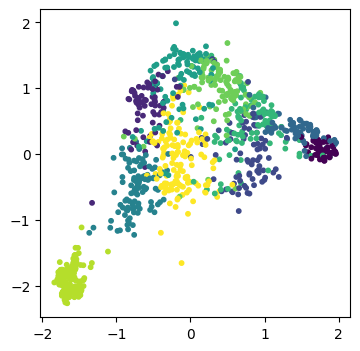

In [190]:
plt.figure(figsize=(4,4))
labels = labels_dic[10]
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, s=10, cmap="viridis")
plt.savefig('../result/figure.svg')
plt.show()


Eigenvalues:
lambda_1: 0.000000
lambda_2: 0.025865
lambda_3: 0.085279
lambda_4: 0.189282
lambda_5: 0.230594
lambda_6: 0.343223
lambda_7: 0.365378
lambda_8: 0.412948
lambda_9: 0.432545
lambda_10: 0.453886
lambda_11: 0.462053
lambda_12: 0.496038
lambda_13: 0.517952
lambda_14: 0.519808
lambda_15: 0.532661


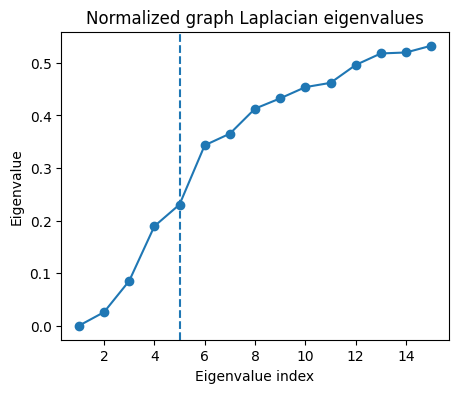

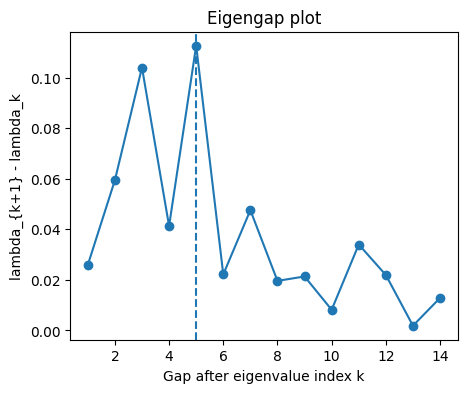

Eigengaps:
gap after k=1: 0.025865
gap after k=2: 0.059414
gap after k=3: 0.104003
gap after k=4: 0.041312
gap after k=5: 0.112628
gap after k=6: 0.022155
gap after k=7: 0.047570
gap after k=8: 0.019597
gap after k=9: 0.021341
gap after k=10: 0.008167
gap after k=11: 0.033985
gap after k=12: 0.021914
gap after k=13: 0.001856
gap after k=14: 0.012853


In [31]:
#Fig. S7a, b
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import SpectralClustering
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from scipy.sparse.csgraph import connected_components

hippo_chr=['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL',  'LATS2',  'NRP1']
hippo_exp=['YAP1','WWTR1','CCN1','AXL']

features = [gene.upper() + '_Chronos' for gene in hippo_chr] + [gene.upper() + '_Expression' for gene in hippo_exp] 
scaled_data = StandardScaler().fit_transform(ch_ex[features]) 
X = scaled_data
# -----------------------------
# 1. Build kNN affinity graph
# -----------------------------
n_neighbors = 30

# distance graph
D = kneighbors_graph(
    X,
    n_neighbors=n_neighbors,
    mode="distance",
    include_self=False
)

# symmetrize distance graph
D = D.maximum(D.T)

# convert distances to RBF-like affinities only on kNN edges
nonzero_dist = D.data
sigma = np.median(nonzero_dist)

A = D.copy()
A.data = np.exp(-(A.data ** 2) / (2 * sigma ** 2))

# check graph connectivity
n_components, component_labels = connected_components(A)

# -----------------------------
# 2. Compute normalized Laplacian eigenvalues
# -----------------------------
L = csgraph.laplacian(A, normed=True)

n_eigs = 15
eigvals, eigvecs = eigsh(L, k=n_eigs, which="SM")
eigvals = np.sort(eigvals)

print("Eigenvalues:")
for i, v in enumerate(eigvals, start=1):
    print(f"lambda_{i}: {v:.6f}")

# plot eigenvalues
plt.figure(figsize=(5, 4))
plt.plot(np.arange(1, n_eigs + 1), eigvals, marker="o")
plt.axvline(5, linestyle="--")
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title("Normalized graph Laplacian eigenvalues")
plt.savefig("../result/figure_eigenvalues.svg", dpi=300, bbox_inches="tight")
plt.show()

# plot eigengaps
eigengaps = np.diff(eigvals)

plt.figure(figsize=(5, 4))
plt.plot(np.arange(1, n_eigs), eigengaps, marker="o")
plt.axvline(5, linestyle="--")
plt.xlabel("Gap after eigenvalue index k")
plt.ylabel("lambda_{k+1} - lambda_k")
plt.title("Eigengap plot")
plt.savefig("../result/figure_eigengaps.svg", dpi=300, bbox_inches="tight") 
plt.show()


print("Eigengaps:")
for k, gap in enumerate(eigengaps, start=1):
    print(f"gap after k={k}: {gap:.6f}")



In [ ]:
#Fig. S7d
def make_knn_affinity(X, n_neighbors=30):
    """
    Build symmetric kNN affinity graph with RBF weights.
    """
    n = X.shape[0]
    n_neighbors = min(n_neighbors, n - 1)

    D = kneighbors_graph(
        X,
        n_neighbors=n_neighbors,
        mode="distance",
        include_self=False
    )

    # Symmetrize distance graph
    D = D.maximum(D.T)

    sigma = np.median(D.data)
    if sigma <= 0:
        sigma = np.mean(D.data[D.data > 0])

    A = D.copy()
    A.data = np.exp(-(A.data ** 2) / (2 * sigma ** 2))

    return A


def spectral_cluster_from_affinity(A, k, random_state=0):
    """
    Spectral clustering from precomputed affinity matrix.
    Uses cluster_qr if available, otherwise discretize.
    """
    try:
        model = SpectralClustering(
            n_clusters=k,
            affinity="precomputed",
            assign_labels="cluster_qr",
            random_state=random_state
        )
        labels = model.fit_predict(A)
    except ValueError:
        model = SpectralClustering(
            n_clusters=k,
            affinity="precomputed",
            assign_labels="discretize",
            random_state=random_state
        )
        labels = model.fit_predict(A)

    return labels

def consensus_clustering(
    X,
    k_values=range(2, 11),
    n_runs=100,
    sample_fraction=0.8,
    n_neighbors=30,
    pac_lower=0.1,
    pac_upper=0.9,
    random_state=0
):
    """
    Repeated subsampling consensus clustering.

    Returns:
        consensus_matrices: dict[k] = consensus matrix C
        pac_scores: dict[k] = PAC score
        co_sample_counts: dict[k] = number of times each pair was co-sampled
    """

    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    n_sub = int(np.floor(sample_fraction * n))

    consensus_matrices = {}
    pac_scores = {}
    co_sample_counts = {}

    for k in k_values:
        print(f"Running K={k}")

        same_cluster_count = np.zeros((n, n), dtype=float)
        co_count = np.zeros((n, n), dtype=float)

        for run in range(n_runs):
            idx = rng.choice(n, size=n_sub, replace=False)
            X_sub = X[idx]

            A_sub = make_knn_affinity(X_sub, n_neighbors=n_neighbors)

            n_components, _ = connected_components(A_sub)
            if n_components > 1:
                # Not fatal, but worth knowing
                print(
                    f"  Warning: K={k}, run={run}, graph has "
                    f"{n_components} connected components"
                )

            labels_sub = spectral_cluster_from_affinity(
                A_sub,
                k=k,
                random_state=run
            )

            # Update co-sampled count
            co_count[np.ix_(idx, idx)] += 1

            # Update same-cluster count
            for cluster_id in np.unique(labels_sub):
                members_sub = np.where(labels_sub == cluster_id)[0]
                members_global = idx[members_sub]
                same_cluster_count[np.ix_(members_global, members_global)] += 1

        # Consensus matrix
        C = np.zeros((n, n), dtype=float)
        valid = co_count > 0
        C[valid] = same_cluster_count[valid] / co_count[valid]

        np.fill_diagonal(C, 1.0)

        consensus_matrices[k] = C
        co_sample_counts[k] = co_count

        # PAC score: proportion of ambiguous pairwise consensus values
        upper = np.triu_indices(n, k=1)
        values = C[upper]

        pac = np.mean((values > pac_lower) & (values < pac_upper))
        pac_scores[k] = pac

        print(f"  PAC={pac:.4f}")

    return consensus_matrices, pac_scores, co_sample_counts

consensus_matrices, pac_scores, co_sample_counts = consensus_clustering(
    X,
    k_values=range(2, 11),
    n_runs=100,
    sample_fraction=0.8,
    n_neighbors=30,
    pac_lower=0.1,
    pac_upper=0.9,
    random_state=0
)


Running K=2
  PAC=0.0488
Running K=3
  PAC=0.0670
Running K=4
  PAC=0.1519
Running K=5
  PAC=0.1310
Running K=6
  PAC=0.2184
Running K=7
  PAC=0.1193
Running K=8
  PAC=0.1707
Running K=9
  PAC=0.1626
Running K=10
  PAC=0.1626


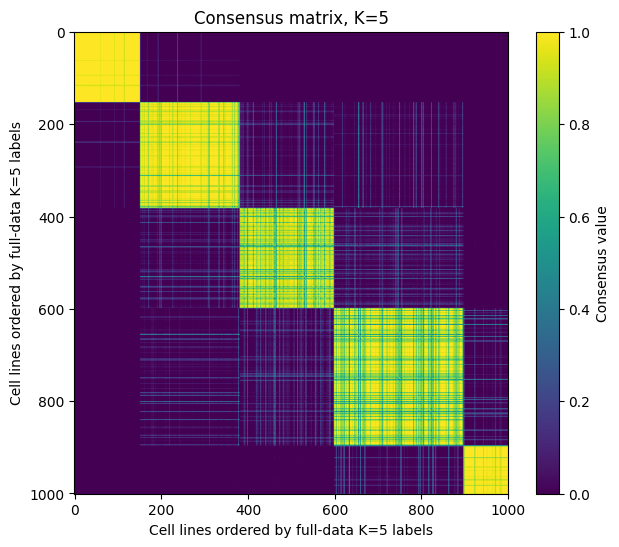

In [ ]:
#Fig. S7c
A_full = make_knn_affinity(X, n_neighbors=30)
labels_5 = spectral_cluster_from_affinity(A_full, k=5, random_state=0)

# Order samples by full-data labels
changed = {0:4, 1:2, 2:0,3:1,4:3}
order = np.argsort([changed[label] for label in labels_5])
#order = np.argsort(labels_5)

C5 = consensus_matrices[5]
C5_ordered = C5[np.ix_(order, order)]

plt.figure(figsize=(7, 6))
plt.imshow(C5_ordered, vmin=0, vmax=1, aspect="auto", cmap="viridis")
plt.colorbar(label="Consensus value")
plt.title("Consensus matrix, K=5")
plt.xlabel("Cell lines ordered by full-data K=5 labels")
plt.ylabel("Cell lines ordered by full-data K=5 labels")
plt.savefig("../result/figure.svg", dpi=300, bbox_inches="tight")
plt.show()